# Problem 1

Consider the lung cancer data and solve the following questions using Python:

---

## Basic EDA Questions

1. Summarize the distribution of Age. Is it normally distributed or skewed?

2. What proportion of individuals are smokers vs non-smokers?

3. Which income group has the highest frequency?

4. What percentage of individuals are exposed to high pollution?

5. What is the overall prevalence of lung disease?

---

## Association & Crosstab

1. Is there an association between Smoking and Lung Disease?

2. Interpret using a contingency table.

---

## Does Pollution Level Affect Lung Disease?

1. Compare lung disease prevalence across income groups.

2. Which factor appears to have the strongest relationship with lung disease?

---

## Statistical Testing

1. Perform a Chi-square test for:
   - Smoking vs Lung Disease
   - Pollution vs Lung Disease

2. When should you use Fisher’s Exact Test instead of Chi-square?

3. Calculate and interpret the Odds Ratio for Smoking and Lung Disease.

---

## Correlation & Interpretation

1. Interpret the correlation between:
   - Smoking and Lung Disease
   - Age and Lung Disease

2. Why is correlation not sufficient for causal inference?

---

## Logistic Regression

1. Fit a logistic regression model:

\[
{LungDisease} ~ {Smoking} + {Age} + \{Pollution} + {Income}
\]

2. Which variables are statistically significant predictors?

3. Interpret the odds ratio of Smoking.

4. What happens to the effect of Smoking after adjusting for Pollution?

---

## Advanced Modeling

1. Add an interaction term:

\[
{Smoking} X {Pollution}
\]

2. Is the interaction significant?

3. Interpret the interaction.

4. Does pollution amplify smoking risk?

---

## Model Evaluation

1. Compute the ROC curve and AUC.

2. Is the model good?

3. What is the confusion matrix?

4. Discuss model accuracy vs sensitivity vs specificity.

---

## Research Question

> “Using the lung disease dataset, perform exploratory data analysis and fit a logistic regression model to identify key determinants of lung disease. Interpret your findings and discuss public health implications.”

## Basic EDA Questions

1. Summarize the distribution of Age. Is it normally distributed or skewed?

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import shapiro

In [3]:
df = pd.read_csv("/content/lung_disease.csv")

In [4]:
print(df.head())

   ID Smoking  Age  Income Pollution LungDisease
0   1     Yes   36     Low      High         Yes
1   2      No   28     Low       Low          No
2   3      No   52  Medium      High          No
3   4      No   39    High      High          No
4   5     Yes   32     Low       Low         Yes


In [5]:
# Summary statistics

print(df['Age'].describe())

count    500.000000
mean      43.904000
std       14.604841
min       20.000000
25%       30.750000
50%       45.000000
75%       56.000000
max       69.000000
Name: Age, dtype: float64


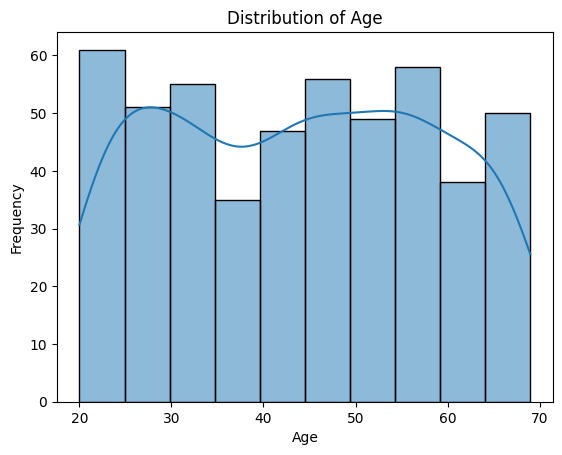

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df['Age'],
    kde=True,
    bins=10
)

plt.title("Distribution of Age")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

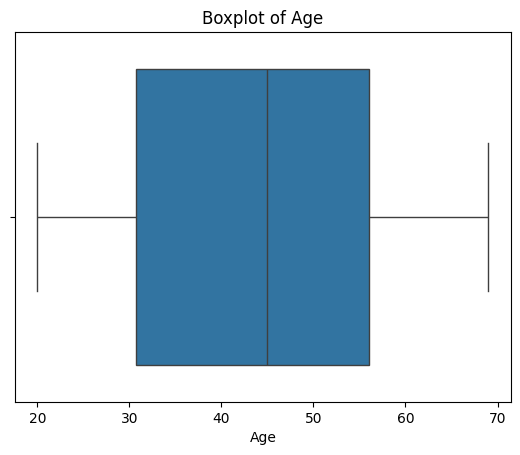

In [7]:
sns.boxplot(
    x=df['Age']
)

plt.title("Boxplot of Age")

plt.show()

In [8]:
#Skewness
print(
    "Skewness:",
    df['Age'].skew()
)

Skewness: 0.012141455267137275


## Normality Test

Using the **Shapiro-Wilk Test**

### Null Hypothesis

\[
H_0 : {Age follows normal distribution}
\]

### Alternative Hypothesis

\[
H_1 : {Age does not follow normal distribution}
\]

In [9]:
from scipy.stats import shapiro

stat, p = shapiro(df['Age'])

print("Shapiro Test Statistic:", stat)
print("P-value:", p)

Shapiro Test Statistic: 0.9488992946952997
P-value: 4.035055085974128e-12


In [10]:
if p > 0.05:
    print("Age is approximately normally distributed")
else:
    print("Age is not normally distributed")

Age is not normally distributed


2. What proportion of individuals are smokers vs non-smokers?




In [11]:
# Count smokers and non-smokers

smoking_counts = df['Smoking'].value_counts()

print(smoking_counts)

Smoking
No     293
Yes    207
Name: count, dtype: int64


In [12]:
# Percentage of smokers and non-smokers

smoking_percentage = (
    df['Smoking'].value_counts(normalize=True)
) * 100

print(smoking_percentage)

Smoking
No     58.6
Yes    41.4
Name: proportion, dtype: float64


3. Which income group has the highest frequency?

In [14]:
# Frequency of income groups

income_counts = df['Income'].value_counts()

print(income_counts)
# Most frequent income group

print(
    "Highest frequency income group is:",
    income_counts.idxmax()
)

Income
Low       204
Medium    197
High       99
Name: count, dtype: int64
Highest frequency income group is: Low


4. What percentage of individuals are exposed to high pollution?

In [15]:
# Percentage exposed to high pollution

high_pollution_percentage = (
    (df['Pollution'] == 'High').mean()
) * 100

print(
    "Percentage exposed to high pollution:",
    high_pollution_percentage
)

Percentage exposed to high pollution: 70.39999999999999


5. What is the overall prevalence of lung disease?

In [16]:
# Overall prevalence of lung disease

lung_disease_percentage = (
    (df['LungDisease'] == 'Yes').mean()
) * 100

print(
    "Overall prevalence of lung disease:",
    lung_disease_percentage
)

Overall prevalence of lung disease: 52.800000000000004


## Association & Crosstab

1. Is there an association between Smoking and Lung Disease?

In [17]:
# Contingency table

table = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print(table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [18]:
# Row percentage table

row_percent = pd.crosstab(
    df['Smoking'],
    df['LungDisease'],
    normalize='index'
) * 100

print(row_percent.round(2))

LungDisease     No    Yes
Smoking                  
No           62.80  37.20
Yes          25.12  74.88


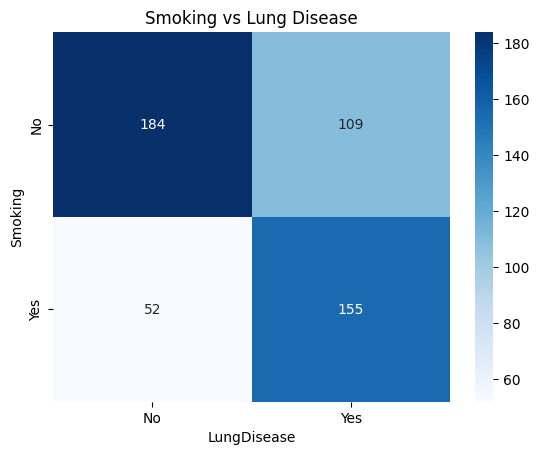

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Smoking vs Lung Disease"
)

plt.show()

**2. Interpret using a contingency table.**

###### Interpretation

The contingency table shows that smokers have a much higher proportion of lung disease compared to non-smokers.

Among smokers, approximately **74.88%** have lung disease, while only **37.20%** of non-smokers have lung disease.

This suggests a strong positive association between smoking and lung disease.

## Does Pollution Level Affect Lung Disease?

1. Compare lung disease prevalence across income groups.



In [23]:
# Income vs Lung Disease

income_table = pd.crosstab(
    df['Income'],
    df['LungDisease']
)

print(income_table)

LungDisease  No  Yes
Income              
High         51   48
Low          90  114
Medium       95  102


In [24]:
# Row percentage table

income_percent = pd.crosstab(
    df['Income'],
    df['LungDisease'],
    normalize='index'
) * 100

print(income_percent.round(2))

LungDisease     No    Yes
Income                   
High         51.52  48.48
Low          44.12  55.88
Medium       48.22  51.78


## Interpretation

The prevalence of lung disease varies across income groups.

Individuals in the **Low income** group have the highest prevalence of lung disease, with approximately **55.88%** affected.

The **Medium income** group has a lung disease prevalence of **51.78%**, while the **High income** group has the lowest prevalence at **48.48%**.

This suggests that lower income groups may be more affected by lung disease compared to higher income groups.

**2. Which factor appears to have the strongest relationship with lung disease?**

In [25]:
print("Smoking vs Lung Disease")
print(row_percent.round(2))

print("\nPollution vs Lung Disease")
print(pollution_percent.round(2))

print("\nIncome vs Lung Disease")
print(income_percent.round(2))

Smoking vs Lung Disease
LungDisease     No    Yes
Smoking                  
No           62.80  37.20
Yes          25.12  74.88

Pollution vs Lung Disease
LungDisease     No    Yes
Pollution                
High         38.64  61.36
Low          67.57  32.43

Income vs Lung Disease
LungDisease     No    Yes
Income                   
High         51.52  48.48
Low          44.12  55.88
Medium       48.22  51.78


## Interpretation

Among the examined factors, **Smoking** appears to have the strongest relationship with lung disease.

Approximately **74.88%** of smokers have lung disease compared to only **37.20%** of non-smokers, showing a large difference between groups.

Pollution also shows a noticeable association, as individuals exposed to high pollution have a higher prevalence of lung disease (**61.36%**) compared to those exposed to low pollution (**32.43%**).

Income shows comparatively smaller differences in lung disease prevalence across groups.

## Statistical Testing

1. Perform a Chi-square test for:
   - Smoking vs Lung Disease
   - Pollution vs Lung Disease

In [26]:
#Smoking vs Lung Disease — Chi-Square Test

from scipy.stats import chi2_contingency

# Contingency table

smoking_table = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print(smoking_table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [27]:
# Chi-square test

chi2, p, dof, expected = chi2_contingency(
    smoking_table
)

print("Chi-square Statistic:", chi2)

print("Degrees of Freedom:", dof)

print("P-value:", p)

Chi-square Statistic: 67.5942649754021
Degrees of Freedom: 1
P-value: 2.0085094601569646e-16


## Interpretation

The Chi-square test results indicate a statistically significant association between Smoking and Lung Disease.

Since the p-value is much smaller than 0.05, we reject the null hypothesis of independence.

This suggests that smoking status is significantly related to lung disease occurrence.

In [29]:
#Pollution vs Lung Disease — Chi-Square Test
# Contingency table

pollution_table = pd.crosstab(
    df['Pollution'],
    df['LungDisease']
)

print(pollution_table)

LungDisease   No  Yes
Pollution            
High         136  216
Low          100   48


In [30]:
# Chi-square test

chi2, p, dof, expected = chi2_contingency(
    pollution_table
)

print("Chi-square Statistic:", chi2)

print("Degrees of Freedom:", dof)

print("P-value:", p)

Chi-square Statistic: 33.84256825473482
Degrees of Freedom: 1
P-value: 5.975692575712951e-09


## Interpretation

The Chi-square test results show a statistically significant association between Pollution Level and Lung Disease.

Since the p-value is less than 0.05, we reject the null hypothesis of independence.

This suggests that pollution level is significantly related to the occurrence of lung disease.

**2. When Should Fisher’s Exact Test Be Used?**

Fisher’s Exact Test should be used instead of the Chi-square test
when sample size is small or when expected cell frequencies
are less than 5 in a contingency table.

**3. Odds Ratio for Smoking and Lung Disease**

In [31]:
print(smoking_table)

LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


In [32]:
#Calculate Odds Ratio
from statsmodels.stats.contingency_tables import Table2x2

# Convert to numpy array

table_array = smoking_table.values

# Odds ratio

oddsratio = Table2x2(
    table_array
)

print(
    "Odds Ratio:",
    oddsratio.oddsratio
)

Odds Ratio: 5.031757233592096


## Interpretation

The odds ratio is approximately **5.03**, which indicates that smokers have about **5 times higher odds** of developing lung disease compared to non-smokers.

This suggests a strong positive association between smoking and lung disease.

## Correlation & Interpretation

1. Interpret the correlation between:
   - Smoking and Lung Disease
   - Age and Lung Disease



In [33]:
# Convert categorical variables to numeric

df['Smoking_num'] = df['Smoking'].map({
    'No': 0,
    'Yes': 1
})

df['LungDisease_num'] = df['LungDisease'].map({
    'No': 0,
    'Yes': 1
})

In [34]:
# Correlation between Smoking and Lung Disease

correlation_smoking = df[
    ['Smoking_num', 'LungDisease_num']
].corr()

print(correlation_smoking)

                 Smoking_num  LungDisease_num
Smoking_num         1.000000         0.371747
LungDisease_num     0.371747         1.000000


## Interpretation

The correlation coefficient between Smoking and Lung Disease is **0.372**, indicating a moderate positive relationship.

This suggests that individuals who smoke are more likely to develop lung disease compared to non-smokers.

**2. Why is correlation not sufficient for causal inference?**


Correlation is not sufficient for causal inference because correlation only measures the strength and direction of association between variables.

A correlation between two variables does not necessarily mean that one variable causes the other.

Other factors, called confounding variables, may influence both variables simultaneously. In addition, correlation cannot establish temporal order or rule out coincidence.

Therefore, further statistical analysis and experimental or longitudinal studies are needed to establish causation.

## Logistic Regression

1. Fit a logistic regression model:

\[
{LungDisease} ~ {Smoking} + {Age} + \{Pollution} + {Income}
\]

2. Which variables are statistically significant predictors?

3. Interpret the odds ratio of Smoking.

4. What happens to the effect of Smoking after adjusting for Pollution?

1. Fit a logistic regression model:

\[
{LungDisease} ~ {Smoking} + {Age} + \{Pollution} + {Income}
\]

In [35]:
import statsmodels.formula.api as smf

In [36]:
# Fit logistic regression model

model = smf.logit(
    'LungDisease_num ~ Smoking_num + Age + C(Pollution) + C(Income)',
    data=df
).fit()

Optimization terminated successfully.
         Current function value: 0.552949
         Iterations 6


In [37]:
# View model summary

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      494
Method:                           MLE   Df Model:                            5
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2005
Time:                        09:35:59   Log-Likelihood:                -276.47
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 3.499e-28
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.1940      0.425     -5.164      0.000      -3.027      -1.361
C(Pollution)[T.Low]    -1.3027      0.235     -5.533      0.000      -1.764      -0.841
C(Income)[T.Low]

## Interpretation

The logistic regression model is statistically significant, indicating that the predictors collectively explain lung disease occurrence.

### Significant Predictors

- **Smoking** is a statistically significant predictor of lung disease (\(p < 0.001\)).
- **Age** is also statistically significant (\(p < 0.001\)).
- **Pollution level** significantly affects lung disease (\(p < 0.001\)).

### Income

The income variables are not statistically significant because their p-values are greater than 0.05.

### Smoking Effect

The positive coefficient for Smoking indicates that smokers have a higher probability of developing lung disease compared to non-smokers.

### Age Effect

The positive coefficient for Age suggests that the probability of lung disease increases with age.

### Pollution Effect

Individuals exposed to low pollution have lower odds of lung disease compared to those exposed to high pollution.

2. Which variables are statistically significant predictors?

In [38]:
# Extract p-values

print(model.pvalues)

Intercept              2.413178e-07
C(Pollution)[T.Low]    3.139044e-08
C(Income)[T.Low]       1.226431e-01
C(Income)[T.Medium]    4.397235e-01
Smoking_num            6.131827e-15
Age                    4.906629e-08
dtype: float64


## Interpretation

The statistically significant predictors of lung disease are:

- **Smoking** (\(p < 0.001\))
- **Age** (\(p < 0.001\))
- **Pollution** (\(p < 0.001\))

These variables have p-values less than 0.05, indicating a significant association with lung disease.

The income variables are not statistically significant because their p-values are greater than 0.05.

3. Interpret the Odds Ratio of Smoking

In [39]:
import numpy as np

# Odds ratios

odds_ratios = np.exp(
    model.params
)

print(odds_ratios)

Intercept              0.111471
C(Pollution)[T.Low]    0.271784
C(Income)[T.Low]       1.552101
C(Income)[T.Medium]    1.246243
Smoking_num            5.485739
Age                    1.040683
dtype: float64


In [40]:
print(
    "Odds Ratio of Smoking:",
    odds_ratios['Smoking_num']
)

Odds Ratio of Smoking: 5.485738801540751


## Interpretation

The odds ratio for Smoking is approximately **5.49**.

This indicates that smokers have about **5.5 times higher odds** of developing lung disease compared to non-smokers, after adjusting for age, pollution, and income.

4. What happens to the effect of Smoking after adjusting for Pollution?

In [41]:
# Logistic regression without Pollution

model_without_pollution = smf.logit(
    'LungDisease_num ~ Smoking_num + Age + C(Income)',
    data=df
).fit()

print(model_without_pollution.summary())

Optimization terminated successfully.
         Current function value: 0.585871
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      495
Method:                           MLE   Df Model:                            4
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.1528
Time:                        09:41:00   Log-Likelihood:                -292.94
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 5.986e-22
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.5652      0.418     -6.138      0.000      -3.384      -1.746
C(

In [42]:
print(
    "Smoking coefficient without Pollution:",
    model_without_pollution.params['Smoking_num']
)

print(
    "Smoking coefficient with Pollution:",
    model.params['Smoking_num']
)

Smoking coefficient without Pollution: 1.6651027434859365
Smoking coefficient with Pollution: 1.7021517795592478


In [43]:
# Odds ratios

or_without_pollution = np.exp(
    model_without_pollution.params['Smoking_num']
)

or_with_pollution = np.exp(
    model.params['Smoking_num']
)

print(
    "Odds Ratio without Pollution:",
    or_without_pollution
)

print(
    "Odds Ratio with Pollution:",
    or_with_pollution
)

Odds Ratio without Pollution: 5.286216346155295
Odds Ratio with Pollution: 5.485738801540751


## Interpretation

The effect of Smoking remains strong even after adjusting for Pollution.

The smoking coefficient and odds ratio changed only slightly after including pollution in the model:

- Odds Ratio without Pollution = **5.29**
- Odds Ratio with Pollution = **5.49**

This suggests that smoking independently contributes to lung disease risk, and its effect is not fully explained by pollution exposure.

## Advanced Modeling

1. Add an interaction term:

\[
{Smoking} X {Pollution}
\]

2. Is the interaction significant?

3. Interpret the interaction.

4. Does pollution amplify smoking risk?

1. Add an interaction term:

\[
{Smoking} X {Pollution}
\]

In [45]:
# Logistic regression with interaction term

interaction_model = smf.logit(
    'LungDisease_num ~ Smoking_num * C(Pollution) + Age + C(Income)',
    data=df
).fit()
print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.552178
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:        LungDisease_num   No. Observations:                  500
Model:                          Logit   Df Residuals:                      493
Method:                           MLE   Df Model:                            6
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2016
Time:                        09:44:44   Log-Likelihood:                -276.09
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 1.341e-27
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -2.1285      0.430     -4.953  

## 2. Is the interaction significant?

The interaction term between Smoking and Pollution is not statistically significant because:

\[
p = 0.382 > 0.05
\]

This indicates that there is insufficient evidence of a significant interaction effect between smoking and pollution on lung disease risk.

## 3. Interpret the interaction

The positive interaction coefficient suggests that the combined effect of smoking and pollution may increase lung disease risk more than their individual effects alone.

However, since the interaction term is not statistically significant, this additional combined effect is not strong enough to conclude a meaningful interaction in the population.

## 4. Does pollution amplify smoking risk?

The interaction coefficient is positive, which suggests that pollution may increase the effect of smoking on lung disease risk.

However, because the interaction term is not statistically significant (\(p > 0.05\)), there is no strong statistical evidence that pollution significantly amplifies smoking risk.

## Model Evaluation

1. Compute the ROC curve and AUC.

2. Is the model good?

3. What is the confusion matrix?

4. Discuss model accuracy vs sensitivity vs specificity.

1. Compute the ROC curve and AUC.

In [46]:
# Predicted probabilities

y_pred_prob = model.predict(df)

In [47]:
#ROC curve and AUC
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

# ROC components

fpr, tpr, thresholds = roc_curve(
    df['LungDisease_num'],
    y_pred_prob
)

# AUC score

auc = roc_auc_score(
    df['LungDisease_num'],
    y_pred_prob
)

print("AUC:", auc)

AUC: 0.7871645480225988


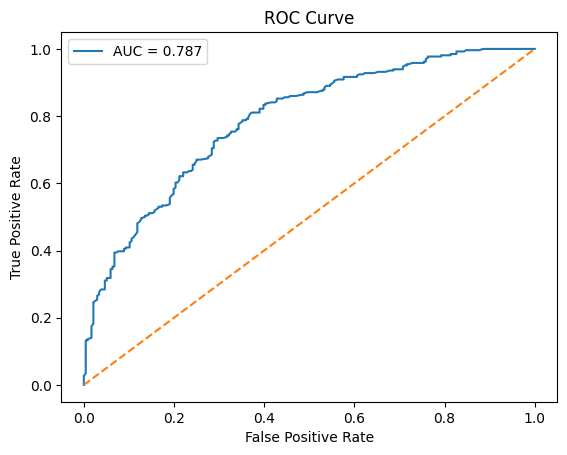

In [48]:
import matplotlib.pyplot as plt

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

2. Is the model good?

## Interpretation

The model appears to be reasonably good because the AUC value is approximately **0.787**.

An AUC between **0.7 and 0.8** indicates **acceptable discrimination ability**, meaning the model can fairly well distinguish between individuals with and without lung disease.

Therefore, the logistic regression model has a good predictive performance, although there is still room for improvement.

3. What is the confusion matrix?

In [49]:
# Predicted classes

y_pred_class = (
    y_pred_prob >= 0.5
).astype(int)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df['LungDisease_num'],
    y_pred_class
)

print(cm)

[[156  80]
 [ 64 200]]


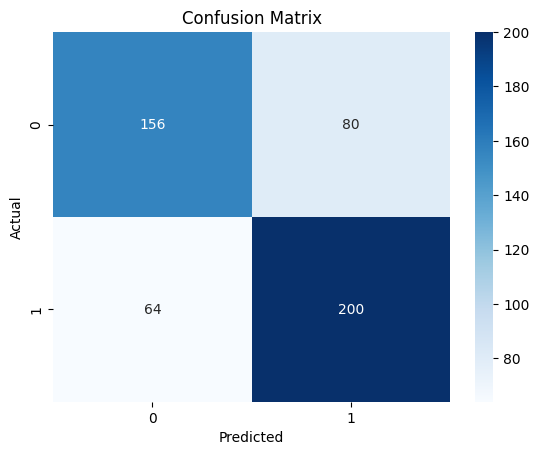

In [50]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Interpretation of Confusion Matrix

The confusion matrix shows that:

- **156** individuals without lung disease were correctly classified (**True Negatives**).
- **200** individuals with lung disease were correctly classified (**True Positives**).
- **80** individuals without lung disease were incorrectly classified as having lung disease (**False Positives**).
- **64** individuals with lung disease were incorrectly classified as not having lung disease (**False Negatives**).

Overall, the model correctly classifies a large number of cases, indicating reasonably good predictive performance.

4. Discuss model accuracy vs sensitivity vs specificity.

In [51]:
from sklearn.metrics import (
    accuracy_score,
    recall_score
)

# Accuracy

accuracy = accuracy_score(
    df['LungDisease_num'],
    y_pred_class
)

# Sensitivity (Recall)

sensitivity = recall_score(
    df['LungDisease_num'],
    y_pred_class
)

# Specificity

tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)

print("Accuracy:", accuracy)

print("Sensitivity:", sensitivity)

print("Specificity:", specificity)

Accuracy: 0.712
Sensitivity: 0.7575757575757576
Specificity: 0.6610169491525424


## Interpretation

The model achieved an accuracy of approximately **71.2%**, meaning that about 71% of the observations were correctly classified.

The sensitivity is approximately **75.8%**, indicating that the model is fairly good at correctly identifying individuals with lung disease.

The specificity is approximately **66.1%**, meaning the model is moderately effective at correctly identifying individuals without lung disease.

Overall, the model performs reasonably well, with better sensitivity than specificity, suggesting it is more effective at detecting lung disease cases than non-disease cases.

## Research Question

> “Using the lung disease dataset, perform exploratory data analysis and fit a logistic regression model to identify key determinants of lung disease. Interpret your findings and discuss public health implications.”

# Research Question

## Exploratory Data Analysis and Logistic Regression Findings

Exploratory data analysis showed noticeable differences in lung disease prevalence across smoking status, pollution exposure, and income groups.

Smokers had a substantially higher prevalence of lung disease compared to non-smokers. Individuals exposed to high pollution also showed a higher proportion of lung disease cases. Lower income groups appeared to have slightly higher lung disease prevalence than higher income groups.

Chi-square tests indicated statistically significant associations between:
- Smoking and Lung Disease
- Pollution and Lung Disease

The odds ratio analysis showed that smokers had approximately **5 times higher odds** of developing lung disease compared to non-smokers.

A logistic regression model was fitted using Smoking, Age, Pollution, and Income as predictors of lung disease.

The model identified:
- Smoking
- Age
- Pollution

as statistically significant predictors of lung disease, while income variables were not statistically significant after adjustment.

The logistic regression results indicated that:
- smokers had significantly higher odds of lung disease,
- increasing age was associated with higher lung disease risk,
- and exposure to high pollution increased the likelihood of lung disease.

The interaction analysis between Smoking and Pollution suggested a positive interaction effect, although the interaction term was not statistically significant.

Model evaluation showed:
- AUC ≈ 0.787
- Accuracy ≈ 71.2%
- Sensitivity ≈ 75.8%
- Specificity ≈ 66.1%

These results indicate that the model has acceptable predictive performance and is reasonably effective at identifying individuals with lung disease.

## Public Health Implications

The findings highlight smoking and pollution exposure as major risk factors for lung disease.

Public health interventions should focus on:
- reducing smoking prevalence,
- improving air quality,
- increasing awareness regarding respiratory health,
- and promoting early screening for high-risk populations.

Policies targeting smoking cessation and environmental pollution control may substantially reduce the burden of lung disease in the population.

**Problem 10**

A study of length of hospital stay, in days, as a function of age, kind of health insurance, and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The dataset is taken from:

UCLA Zero-Truncated Poisson Dataset

Fit the Zero-Truncated Poisson regression generalized linear model (GLM) to identify the factors associated with hospital length of stay. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from statsmodels.discrete.truncated_model import TruncatedLFPoisson

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [5]:
pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.6 MB/s eta 0:00:00


In [7]:
import pandas as pd
import pyreadstat
import urllib.request

In [8]:
url = "https://stats.idre.ucla.edu/stat/data/ztp.dta"

urllib.request.urlretrieve(
    url,
    "ztp.dta"
)

('ztp.dta', <http.client.HTTPMessage at 0x7b0e8dee7080>)

In [9]:
df, meta = pyreadstat.read_dta(
    "ztp.dta"
)

In [10]:
df.head()

,stay,age,hmo,died
0,4,4,0,0.0
1,9,4,1,0.0
2,3,7,1,1.0
3,9,6,0,0.0
4,1,7,0,1.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1493 entries, 0 to 1492
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   stay    1493 non-null   int64  
 1   age     1493 non-null   int64  
 2   hmo     1493 non-null   int64  
 3   died    1493 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 46.8 KB


In [12]:
#Convert Variables
df['hmo'] = df['hmo'].astype('category')

df['died'] = df['died'].astype('category')

In [13]:
df.describe()

,stay,age
count,1493.000000,1493.000000
mean,9.728734,5.233758
std,8.132908,1.669273
min,1.000000,1.000000
25%,4.000000,4.000000
50%,8.000000,5.000000
75%,13.000000,6.000000
max,74.000000,9.000000


In [14]:
#Check Zero Counts
print(
    "Number of zeros:",
    (df['stay'] == 0).sum()
)

Number of zeros: 0


In [15]:
#Prepare Variables

#Response variable:

y = df['stay']

In [19]:
X = pd.get_dummies(
    df[['age', 'hmo', 'died']],
    drop_first=True
)

X = X.astype(float)

X = sm.add_constant(X)

In [20]:
#Fit Zero-Truncated Poisson Model

#Model:stay∼age+hmo+died
ztp_model = TruncatedLFPoisson(
    endog=y,
    exog=X
).fit()

Optimization terminated successfully.
         Current function value: 4.627461
         Iterations: 4
         Function evaluations: 6
         Gradient evaluations: 6


In [21]:
print(ztp_model.summary())

                    TruncatedLFPoisson Regression Results                     
Dep. Variable:                   stay   No. Observations:                 1493
Model:             TruncatedLFPoisson   Df Residuals:                     1489
Method:                           MLE   Df Model:                            3
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.01294
Time:                        12:54:21   Log-Likelihood:                -6908.8
converged:                       True   LL-Null:                       -6999.4
Covariance Type:            nonrobust   LLR p-value:                 5.022e-39
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4358      0.027     89.118      0.000       2.382       2.489
age           -0.0144      0.005     -2.868      0.004      -0.024      -0.005
hmo_1         -0.1359      0.024     -5.724      0.0

**Interpretation of Zero-Truncated Poisson Regression Results**

The Zero-Truncated Poisson regression model was used to identify factors associated with hospital length of stay, where zero-day stays are excluded from the dataset.

The overall model is statistically significant:

Likelihood Ratio p-value = 5.02 × 10⁻³⁹

This indicates that the predictors collectively help explain variation in hospital stay duration.

**Interpretation of Predictors**

**Age:**

Coefficient = -0.0144
p-value = 0.004

Age is statistically significant.

The negative coefficient suggests that higher age is associated with a slightly shorter expected hospital stay.

**Insurance Type (hmo_1)**

Coefficient = -0.1359
p-value < 0.001

Insurance type is statistically significant.

Patients with HMO insurance tend to have shorter hospital stays compared to the reference group.

**Mortality Status (died_1.0)**

Coefficient = -0.2038
p-value < 0.001

Mortality status is statistically significant.

Patients in the died = 1 category are associated with shorter expected hospital stays compared to the reference category.

**Interpretation of Coefficients**

The Zero-Truncated Poisson model uses a log link:

log(μ)=β0 +β1X1+⋯


Negative coefficients reduce the expected hospital stay duration.


**Overall Conclusion**

The analysis suggests that:

age,
insurance type,
and mortality status

are significant predictors of hospital length of stay. The Zero-Truncated Poisson model was appropriate because the dataset excludes zero-day hospital stays.

**Problem 11**

A study of length of hospital stay, in days, as a function of age, kind of health insurance, and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The dataset is taken from:

UCLA Zero-Truncated Dataset

Fit the Zero-Truncated Negative Binomial regression generalized linear model (GLM) to identify the factors associated with hospital length of stay. Interpret the results.

In [2]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from statsmodels.discrete.truncated_model import TruncatedLFNegativeBinomialP

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


import urllib.request

In [3]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 25.4 MB/s eta 0:00:00


In [4]:
import pyreadstat

In [5]:
url = "https://stats.idre.ucla.edu/stat/data/ztp.dta"

urllib.request.urlretrieve(
    url,
    "ztp.dta"
)

('ztp.dta', <http.client.HTTPMessage at 0x7e15ad235520>)

In [6]:
df, meta = pyreadstat.read_dta(
    "ztp.dta"
)

In [7]:
df.head()

,stay,age,hmo,died
0,4,4,0,0.0
1,9,4,1,0.0
2,3,7,1,1.0
3,9,6,0,0.0
4,1,7,0,1.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1493 entries, 0 to 1492
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   stay    1493 non-null   int64  
 1   age     1493 non-null   int64  
 2   hmo     1493 non-null   int64  
 3   died    1493 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 46.8 KB


In [9]:
#Convert Variables
df['hmo'] = df['hmo'].astype('category')

df['died'] = df['died'].astype('category')

In [10]:
#Check Overdispersion
print(
    "Mean:",
    df['stay'].mean()
)

print(
    "Variance:",
    df['stay'].var()
)

#Variance >> Mean so overdispersion exists

Mean: 9.728734092431345
Variance: 66.14419390578749


In [11]:
#Check Zero Counts
print(
    "Number of zeros:",
    (df['stay'] == 0).sum()
)

Number of zeros: 0


In [12]:
#Prepare Variables

#Response variable:

y = df['stay']

#Predictors:

X = pd.get_dummies(
    df[['age', 'hmo', 'died']],
    drop_first=True
)

#Convert to numeric:

X = X.astype(float)

#Add constant:

X = sm.add_constant(X)

In [13]:
#Fit Zero-Truncated Negative Binomial Model

#Model:stay∼age+hmo+died
ztnb_model = TruncatedLFNegativeBinomialP(
    endog=y,
    exog=X
).fit()

Optimization terminated successfully.
         Current function value: 3.185050
         Iterations: 16
         Function evaluations: 18
         Gradient evaluations: 18


In [14]:
print(ztnb_model.summary())

                    TruncatedLFNegativeBinomialP Regression Results                     
Dep. Variable:                             stay   No. Observations:                 1493
Model:             TruncatedLFNegativeBinomialP   Df Residuals:                     1488
Method:                                     MLE   Df Model:                            3
Date:                          Sun, 10 May 2026   Pseudo R-squ.:                0.003263
Time:                                  13:06:20   Log-Likelihood:                -4755.3
converged:                                 True   LL-Null:                       -4770.8
Covariance Type:                      nonrobust   LLR p-value:                 7.955e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.4083      0.072     33.457      0.000       2.267       2.549
age           -0.0157      0.013     -1.197      0.

# Interpretation of Zero-Truncated Negative Binomial Regression Results

print("""
The Zero-Truncated Negative Binomial regression model was used to analyze hospital length of stay while accounting for overdispersion and the absence of zero-day stays.

The overall model is statistically significant because the Likelihood Ratio p-value is less than 0.05. This indicates that the predictors collectively help explain variation in hospital stay duration.

Interpretation of Predictors:

1. Age
- Coefficient = -0.0157
- P-value = 0.231

Age is not statistically significant because p > 0.05.
There is no strong evidence that age affects hospital stay duration in this model.

2. Insurance Type (hmo_1)
- Coefficient = -0.1471
- P-value = 0.013

Insurance type is statistically significant.
Patients with HMO insurance tend to have shorter hospital stays compared to the reference insurance group.

3. Mortality Status (died_1.0)
- Coefficient = -0.2178
- P-value < 0.001

Mortality status is statistically significant.
Patients in the died = 1 category are associated with shorter expected hospital stays compared to the reference category.

4. Overdispersion Parameter (alpha)
- Alpha = 0.5663
- P-value < 0.001

The significant positive alpha value indicates overdispersion exists in the data.
This supports the use of the Negative Binomial model instead of the Poisson model.

Overall Conclusion:
The analysis suggests that insurance type and mortality status significantly affect hospital length of stay, while age does not show a statistically significant effect. The Zero-Truncated Negative Binomial model is appropriate because the data are overdispersed and exclude zero-day hospital stays.
""")

#**Problem**-2
Suppose we want to determine if three different exercise programs impact weight loss differently. We recruit 90 people to participate in an experiment in which we randomly assign (using uniform distribution) 30 people to follow either Program A, Program B, or Program C for one month. The predictor variable being studied is the exercise program, and the response variable is weight loss, measured in pounds.

Conduct a one-way ANOVA to determine if there is a statistically significant difference between the resulting weight loss from the three programs, check the model assumptions, and analyze treatment differences.

In [30]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [31]:
#Create dataset
np.random.seed(42)

A = np.random.normal(loc=5, scale=1.5, size=30)
B = np.random.normal(loc=8, scale=1.5, size=30)
C = np.random.normal(loc=4, scale=1.5, size=30)

In [32]:
#Combine into DataFrame
df = pd.DataFrame({
    'WeightLoss': np.concatenate([A, B, C]),
    'Program': ['A']*30 + ['B']*30 + ['C']*30
})

df.head(35)

,WeightLoss,Program
0,5.745071,A
1,4.792604,A
2,5.971533,A
3,7.284545,A
4,4.648770,A
5,4.648795,A
6,7.368819,A
7,6.151152,A
8,4.295788,A
9,5.813840,A


In [33]:
###Basic EDA##
#Group Means
df.groupby('Program')['WeightLoss'].mean()

,WeightLoss
Program,
A,4.717780
B,7.818256
C,4.019327


In [34]:
#Group Standard Deviations
df.groupby('Program')['WeightLoss'].std()

,WeightLoss
Program,
A,1.350010
B,1.396653
C,1.487975


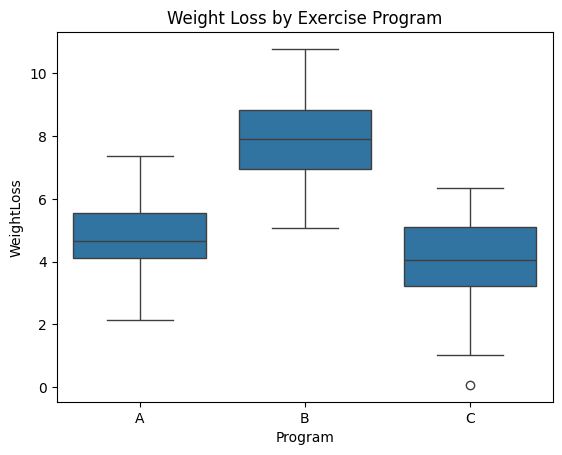

In [35]:
#Boxplot
sns.boxplot(x='Program', y='WeightLoss', data=df)

plt.title("Weight Loss by Exercise Program")

plt.show()

The boxplot shows that weight loss differs across the three exercise programs.

Program B has the highest median weight loss, indicating it is the most effective program overall.
Program A shows moderate weight loss with less variability.
Program C has the lowest median weight loss and includes a possible outlier near 0.

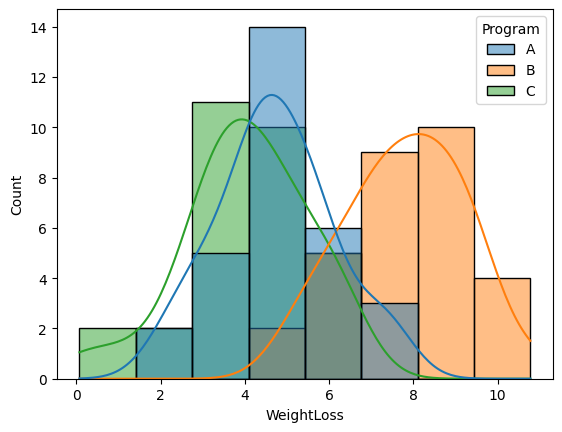

In [36]:
#Distribution Plot
sns.histplot(data=df, x='WeightLoss', hue='Program', kde=True)

plt.show()

##ONE way ANOVA test
ANOVA Assumptions

Before ANOVA we check:


1.   Independence
2.   Normality
3.   Equal Variance



In [37]:
#Nomality check(Shapiro-wilk test)
for group in df['Program'].unique():

    stat, p = stats.shapiro(
        df[df['Program']==group]['WeightLoss']
    )

    print(group)
    print("P-value:", p)
    print()

A
P-value: 0.686805494291708

B
P-value: 0.9129582559088034

C
P-value: 0.36537361581254685



SInce p > 0.05 so it is normal

In [38]:
#Homogeneity of Variance

#Levene’s Test

stat, p = stats.levene(A, B, C)

print("P-value:", p)

P-value: 0.8626638812717601


Since p > 0.05 so equal variances

In [40]:
del C

In [41]:
model = ols(
    'WeightLoss ~ C(Program)',
    data=df
).fit()

In [42]:
#ANOVA Table
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                sum_sq    df          F        PR(>F)
C(Program)  245.326539   2.0  61.462398  2.287256e-17
Residual    173.629808  87.0        NaN           NaN


The one-way ANOVA results show that there is a statistically significant difference in mean weight loss among the three exercise programs.

The F-statistic is 61.46, which is quite large.
The p-value is 2.29 × 10⁻¹⁷, which is much smaller than 0.05.

Since:

p<0.05

p<0.05

we reject the null hypothesis that all program means are equal.

This indicates that at least one exercise program produces a significantly different average weight loss compared to the others.

In [43]:
#Post Hoc Test (Tukey HSD)
tukey = pairwise_tukeyhsd(
    endog=df['WeightLoss'],
    groups=df['Program'],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B   3.1005    0.0  2.2307  3.9702   True
     A      C  -0.6985 0.1406 -1.5682  0.1713  False
     B      C  -3.7989    0.0 -4.6687 -2.9292   True
----------------------------------------------------


**Interpretation of Tukey HSD Test**

The Tukey HSD post hoc test was conducted to identify which exercise programs differ significantly in mean weight loss.

Results show:

Program B differs significantly from Program A (p < 0.05).
Program B also differs significantly from Program C (p < 0.05).
There is no significant difference between Program A and Program C (p = 0.1406).

Program B produced the highest average weight loss, indicating that it is significantly more effective than both Programs A and C.

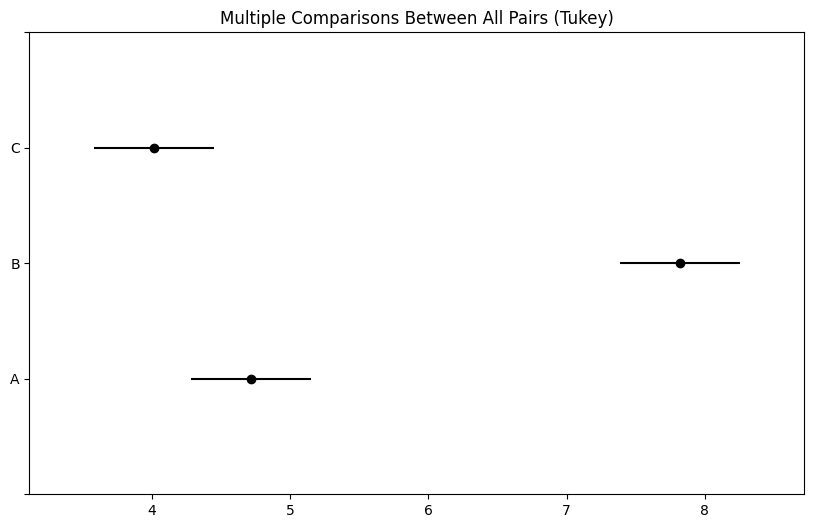

In [44]:
tukey.plot_simultaneous()

plt.show()

In [46]:
residuals = model.resid

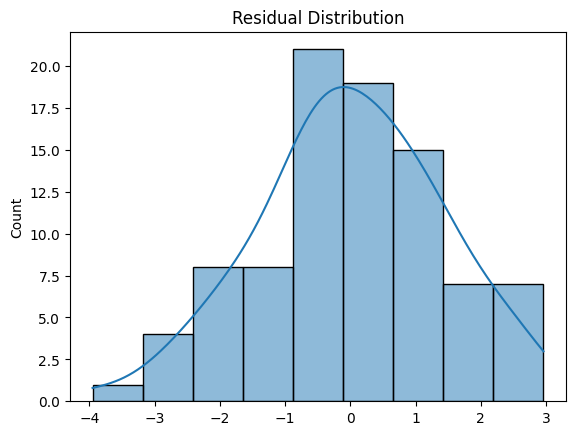

In [47]:
sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

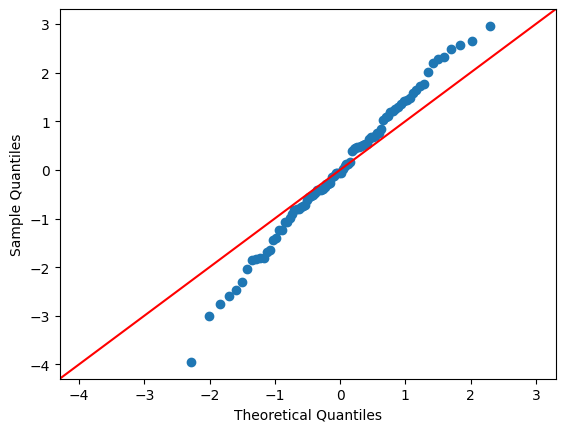

In [48]:
sm.qqplot(residuals, line='45')

plt.show()

The residual is quite normally distributed

**Problem 3**

Consider the Anemia Levels in Nigeria dataset:
(Kaggle Dataset - Factors Affecting Children Anemia Level
), which can be downloaded from Kaggle. The dataset comes from the 2018 Nigeria Demographic and Health Surveys (NDHS). It explores the impact of mothers' age and socioeconomic factors on anemia levels among children aged 0–59 months across Nigeria’s 36 states and the Federal Capital Territory. Based on the above data, create a contingency table, apply chi-square test, formulate hypothesis, create a contribution diagram, and interpret the findings.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

In [2]:
#load dataset

df = pd.read_csv("/content/children anemia.csv")

In [3]:
df.columns

Index(['Age in 5-year groups', 'Type of place of residence',
       'Highest educational level', 'Wealth index combined',
       'Births in last five years', 'Age of respondent at 1st birth',
       'Hemoglobin level adjusted for altitude and smoking (g/dl - 1 decimal)',
       'Anemia level',
       'Have mosquito bed net for sleeping (from household questionnaire)',
       'Smokes cigarettes', 'Current marital status',
       'Currently residing with husband/partner', 'When child put to breast',
       'Had fever in last two weeks',
       'Hemoglobin level adjusted for altitude (g/dl - 1 decimal)',
       'Anemia level.1', 'Taking iron pills, sprinkles or syrup'],
      dtype='object')

In [4]:
#Select Required Variables
data = df[[
    'Highest educational level',
    'Anemia level'
]]

In [5]:
#Remove Missing Values
data = data.dropna()

In [6]:
data.shape

(13136, 2)

In [7]:
#View Unique Categories
print(data['Highest educational level'].unique())

print(data['Anemia level'].unique())

['Secondary' 'Higher' 'No education' 'Primary']
['Moderate' 'Mild' 'Not anemic' 'Severe']


In [8]:
#Create Contingency Table
table = pd.crosstab(
    data['Highest educational level'],
    data['Anemia level']
)

print(table)

Anemia level               Mild  Moderate  Not anemic  Severe
Highest educational level                                    
Higher                      296       238         591      14
No education               1450      1769        1874     113
Primary                     608       645         900      42
Secondary                  1240      1322        1972      62


In [9]:
#Percentage Table


row_percent = pd.crosstab(
    data['Highest educational level'],
    data['Anemia level'],
    normalize='index'
) * 100

print(row_percent.round(2))

Anemia level                Mild  Moderate  Not anemic  Severe
Highest educational level                                     
Higher                     25.99     20.90       51.89    1.23
No education               27.85     33.98       36.00    2.17
Primary                    27.70     29.38       41.00    1.91
Secondary                  26.98     28.76       42.91    1.35


Hypotheses
**Null Hypothesis**
H0
	​ :Educational level and anemia level are independent


**Alternative Hypothesis**
H1 :Educational level and anemia level are associated



In [10]:
#Chi-Square Test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

Chi-square Statistic: 142.86240492075743
Degrees of Freedom: 9
P-value: 2.644147441640121e-26


**Interpretation of Chi-Square Test**

The chi-square test results indicate a statistically significant association between educational level and anemia level.

Chi-square statistic = 142.86
Degrees of freedom = 9
p-value = 2.64 × 10⁻²⁶

Since:

p<0.05

we reject the null hypothesis of independence.

This suggests that anemia levels vary significantly across different educational levels, indicating that educational status may be an important factor related to child anemia outcomes.

In [11]:
#Chi-Square Contribution Matrix
contribution = ((table - expected)**2) / expected

print(contribution.round(2))

Anemia level               Mild  Moderate  Not anemic  Severe
Highest educational level                                    
Higher                     0.78     32.96       35.54    1.82
No education               0.46     23.91       27.49    5.03
Primary                    0.09      0.55        0.08    0.30
Secondary                  0.24      3.37        5.87    4.38


**Interpretation of Contribution Matrix**

The contribution matrix shows which combinations of educational level and anemia level contribute most to the chi-square statistic.

The largest contributions are observed for:

Higher education × Not anemic (35.54)
Higher education × Moderate anemia (32.96)
No education × Not anemic (27.49)
No education × Moderate anemia (23.91)

These large values indicate that these categories are mainly responsible for the significant association between educational level and anemia status.

The results suggest that children’s anemia outcomes differ considerably across maternal educational groups, especially between higher education and no education categories.

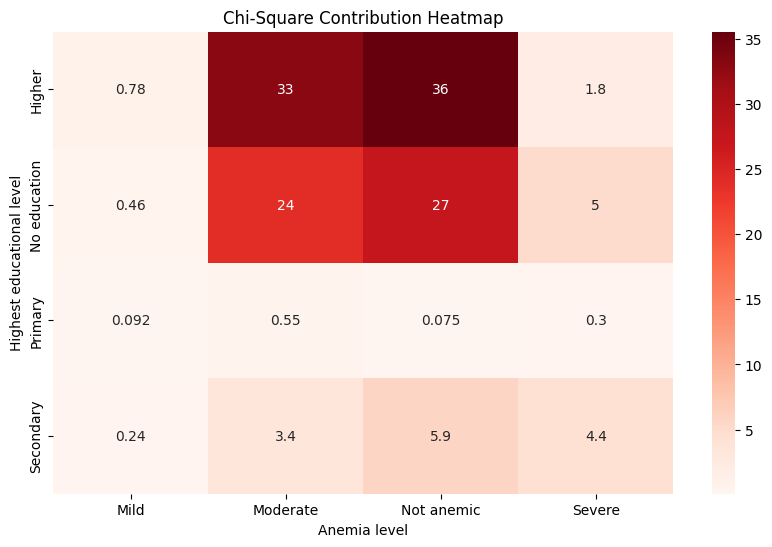

In [12]:
#Contribution Heatmap/diagram
plt.figure(figsize=(10,6))

sns.heatmap(
    contribution,
    annot=True,
    cmap='Reds'
)

plt.title("Chi-Square Contribution Heatmap")

plt.show()

Interpretation of Heatmap

The heatmap visualizes the contribution of each cell to the overall chi-square statistic.

Darker red cells indicate higher contributions and stronger deviations from expected frequencies.
The cells for:
Higher education × Not anemic
Higher education × Moderate anemia
No education × Not anemic
No education × Moderate anemia

show the largest contributions.

This means these categories are the main drivers of the significant association between educational level and anemia status.

In contrast, the Primary education group shows very small contribution values, indicating little influence on the chi-square result.

**Problem 4**

Suppose there are three drug treatments (Drug A, Drug B, and Drug C) with the outcome of disease or no disease. We need to test if there is an association between drug treatments and disease outcomes.

Treatment	No Disease	Disease
Drug A	40	10
Drug B	10	40
Drug C	25	25

Perform Fisher’s exact test for the above contingency table, conduct a post-hoc test for Fisher’s exact test, and interpret your findings.

In [1]:
import pandas as pd
import numpy as np

from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Create Contingency Table
table = pd.DataFrame({
    'No_Disease': [40, 10, 25],
    'Disease': [10, 40, 25]
},
index=['Drug_A', 'Drug_B', 'Drug_C'])

print(table)


        No_Disease  Disease
Drug_A          40       10
Drug_B          10       40
Drug_C          25       25


In [3]:
#Overall Association Test
#Since Fisher’s Exact Test in scipy works directly only for 2×2 tables, we first use Chi-Square to check overall association.
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p)

Chi-square Statistic: 36.0
Degrees of Freedom: 2
P-value: 1.522997974471264e-08


**Interpretation of Overall Association Test**

The chi-square test results indicate a statistically significant association between drug treatment and disease outcome.

Chi-square statistic = 36.0
Degrees of freedom = 2
p-value = 1.52 × 10⁻⁸

Since:

p<0.05

we reject the null hypothesis of independence.

This suggests that disease outcomes differ significantly across the three drug treatments, indicating that treatment type may influence disease status.

**Pairwise Fisher’s Exact Tests**

We compare drugs pairwise:

A vs B
A vs C
B vs C



**Hypotheses**

Null Hypothesis

H0 :Treatment and disease outcome are independent

Alternative Hypothesis

H1 :Treatment and disease outcome are associated

In [4]:
#A vs B
AB = np.array([
    [40, 10],
    [10, 40]
])

oddsratio_AB, p_AB = fisher_exact(AB)

print("A vs B")
print("Odds Ratio:", oddsratio_AB)
print("P-value:", p_AB)

A vs B
Odds Ratio: 16.0
P-value: 2.2221008148312167e-09


In [5]:
#A vs C
AC = np.array([
    [40, 10],
    [25, 25]
])

oddsratio_AC, p_AC = fisher_exact(AC)

print("A vs C")
print("Odds Ratio:", oddsratio_AC)
print("P-value:", p_AC)

A vs C
Odds Ratio: 4.0
P-value: 0.0030520593364333462


In [6]:
#B vs C
BC = np.array([
    [10, 40],
    [25, 25]
])

oddsratio_BC, p_BC = fisher_exact(BC)

print("B vs C")
print("Odds Ratio:", oddsratio_BC)
print("P-value:", p_BC)

B vs C
Odds Ratio: 0.25
P-value: 0.0030520593364333462


In [8]:
#Multiple Testing Correction

#Bonferroni correction:

p_values = [p_AB, p_AC, p_BC]

adjusted = multipletests(
    p_values,
    method='bonferroni'
)

print("Adjusted P-values:")
print(adjusted[1])

Adjusted P-values:
[6.66630244e-09 9.15617801e-03 9.15617801e-03]


In [9]:
#Create Summary Table
results = pd.DataFrame({
    'Comparison': ['A vs B', 'A vs C', 'B vs C'],
    'P-value': p_values,
    'Adjusted P-value': adjusted[1]
})

print(results)

  Comparison       P-value  Adjusted P-value
0     A vs B  2.222101e-09      6.666302e-09
1     A vs C  3.052059e-03      9.156178e-03
2     B vs C  3.052059e-03      9.156178e-03


**Interpretation of Pairwise Fisher’s Exact Tests**

The pairwise Fisher’s exact tests with Bonferroni correction show significant differences between all drug treatment pairs.

Drug A vs Drug B: adjusted p-value = 6.67 × 10⁻⁹
Drug A vs Drug C: adjusted p-value = 0.009
Drug B vs Drug C: adjusted p-value = 0.009

Since all adjusted p-values are less than 0.05, we conclude that the disease outcomes differ significantly among all treatment groups.

The strongest difference is observed between Drug A and Drug B, suggesting these two treatments have substantially different effects on disease outcomes.

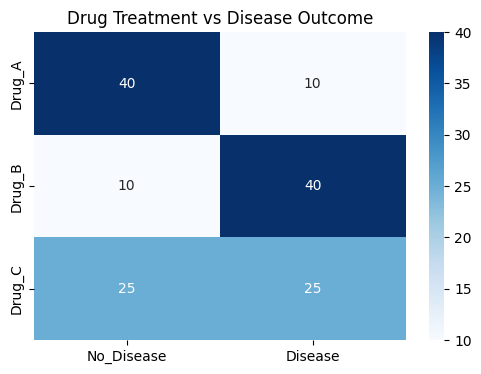

In [10]:
plt.figure(figsize=(6,4))

sns.heatmap(
    table,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Drug Treatment vs Disease Outcome")

plt.show()

**Problem 5**

A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point average), and prestige of the undergraduate institution, affect admission into graduate school. The response variable, admit/don’t admit, is a binary variable. The dataset is taken from:

UCLA Binary Dataset

Fit logistic generalized linear models (GLMs) to identify the factors affecting admission into graduate school. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
#load data
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"

df = pd.read_csv(url)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB


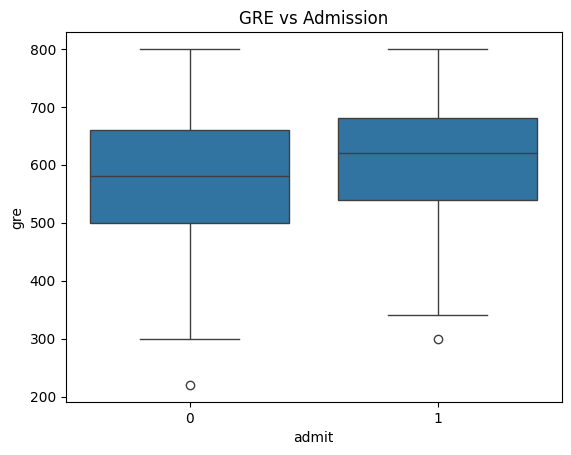

In [4]:
##Exploratory Data Analysis
df.describe()
sns.boxplot(x='admit', y='gre', data=df)

plt.title("GRE vs Admission")

plt.show()

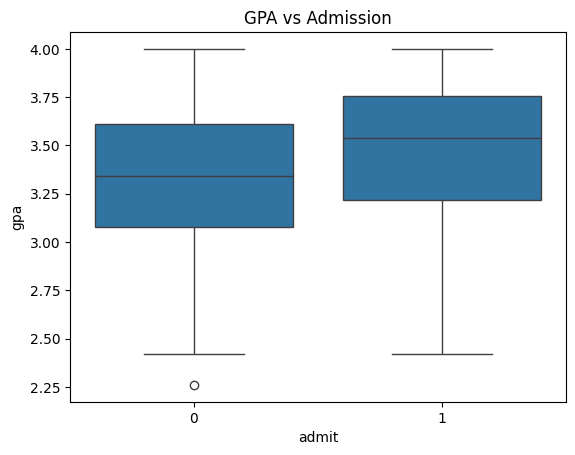

In [5]:
sns.boxplot(x='admit', y='gpa', data=df)

plt.title("GPA vs Admission")

plt.show()

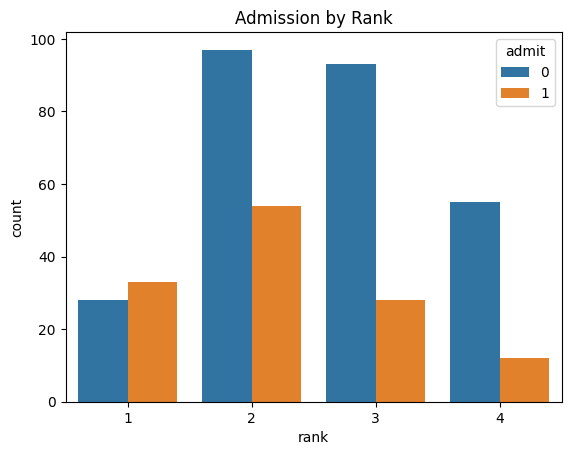

In [6]:
sns.countplot(x='rank', hue='admit', data=df)

plt.title("Admission by Rank")

plt.show()

In [7]:
#Convert Rank into Categorical Variable
df['rank'] = df['rank'].astype('category')

Fit Logistic Regression Model

Model:

admit∼gre+gpa+rank

admit∼gre+gpa+rank

In [8]:
model = smf.logit(
    'admit ~ gre + gpa + rank',
    data=df
).fit()

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6


In [9]:
print(model.summary())

                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Sun, 10 May 2026   Pseudo R-squ.:                 0.08292
Time:                        11:40:42   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9900      1.140     -3.500      0.000      -6.224      -1.756
rank[T.2]     -0.6754      0.316     -2.134      0.033      -1.296      -0.055
rank[T.3]     -1.3402      0.345     -3.881      0.0

**Interpretation of Logistic Regression Results**

The logistic regression model examines how GRE score, GPA, and undergraduate institution rank affect the probability of admission into graduate school.

The overall model is statistically significant:

Likelihood Ratio p-value = 7.58 × 10⁻⁸

This indicates that the predictors collectively help explain admission outcomes.

**Interpretation of Predictors**

**GRE Score**

Coefficient = 0.0023
p-value = 0.038

Since p < 0.05, GRE is a statistically significant predictor.

A higher GRE score increases the likelihood of admission.

**GPA**

Coefficient = 0.8040
p-value = 0.015

GPA is also statistically significant.

Students with higher GPAs are more likely to be admitted into graduate school.

**Institution Rank**

Compared to rank 1 institutions (reference category):

Rank 2 coefficient = -0.6754
Rank 3 coefficient = -1.3402
Rank 4 coefficient = -1.5515

All coefficients are negative and statistically significant.

This suggests that students from lower prestige institutions have lower odds of admission compared to students from rank 1 institutions.

**Model Performance**

Pseudo R² = 0.0829

This indicates the model explains a modest proportion of variability in admission outcomes, which is common in logistic regression for real-world admission data.

**Overall Conclusion**

The analysis suggests that:

higher GRE scores,
higher GPA,
and graduating from more prestigious institutions

increase the probability of admission into graduate school.

In [10]:
#odd ratios
odds_ratios = np.exp(model.params)

print(odds_ratios)

Intercept    0.018500
rank[T.2]    0.508931
rank[T.3]    0.261792
rank[T.4]    0.211938
gre          1.002267
gpa          2.234545
dtype: float64


**Interpretation of Odds Ratios**

The odds ratios explain how each predictor affects the odds of admission to graduate school.

**GRE**

Odds Ratio = 1.002

This means that for each one-unit increase in GRE score, the odds of admission increase by about 0.2%, holding other variables constant.

**GPA**

Odds Ratio = 2.23

This indicates that a one-unit increase in GPA multiplies the odds of admission by about 2.23 times.

Higher GPA substantially increases admission chances.

**Institution Rank**

Rank 1 is the reference category.

Compared to rank 1 institutions:

Rank 2 OR = 0.51
Rank 3 OR = 0.26
Rank 4 OR = 0.21

Since these odds ratios are less than 1, students from lower-ranked institutions have lower odds of admission.

For example:

Students from rank 4 institutions have about 79% lower odds of admission compared to students from rank 1 institutions.

**Problem 6**

The number of awards earned by students at one high school. Predictors of the number of awards earned include the type of program in which the student was enrolled (e.g., vocational, general, or academic) and the score on their final exam in math. The dataset is taken from:

UCLA Poisson Dataset

Fit the Poisson generalized linear model (GLM) to identify the factors associated with the number of awards earned by students at one high school. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [2]:
#load dataset
url = "https://stats.idre.ucla.edu/stat/data/poisson_sim.csv"

df = pd.read_csv(url)

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          200 non-null    int64
 1   num_awards  200 non-null    int64
 2   prog        200 non-null    int64
 3   math        200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


In [4]:
#Convert Program to Categorical
df['prog'] = df['prog'].astype('category')

In [5]:
#Exploratory Data Analysis
df.describe()

,id,num_awards,math
count,200.000000,200.000000,200.000000
mean,100.500000,0.630000,52.645000
std,57.879185,1.052921,9.368448
min,1.000000,0.000000,33.000000
25%,50.750000,0.000000,45.000000
50%,100.500000,0.000000,52.000000
75%,150.250000,1.000000,59.000000
max,200.000000,6.000000,75.000000


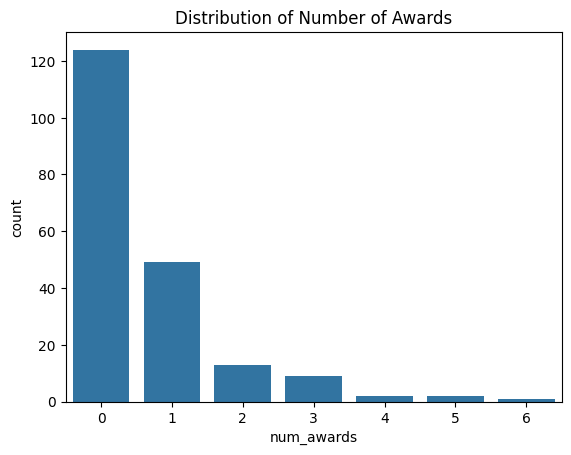

In [6]:
#Distribution of Awards
sns.countplot(x='num_awards', data=df)

plt.title("Distribution of Number of Awards")

plt.show()

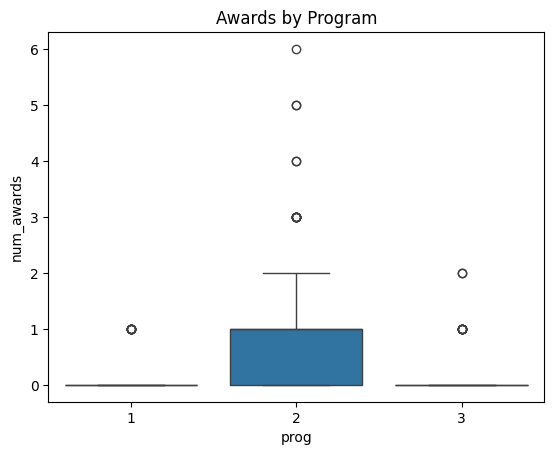

In [7]:
#Awards by Program
sns.boxplot(
    x='prog',
    y='num_awards',
    data=df
)

plt.title("Awards by Program")

plt.show()

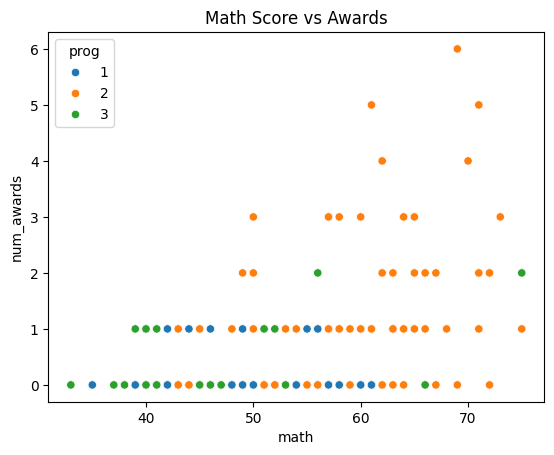

In [8]:
#Math Score vs Awards
sns.scatterplot(
    x='math',
    y='num_awards',
    hue='prog',
    data=df
)

plt.title("Math Score vs Awards")

plt.show()

In [9]:
#Fit Poisson Regression Model
model = smf.glm(
    formula='num_awards ~ prog + math',
    data=df,
    family=sm.families.Poisson()
).fit()

In [10]:
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             num_awards   No. Observations:                  200
Model:                            GLM   Df Residuals:                      196
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -182.75
Date:                Sun, 10 May 2026   Deviance:                       189.45
Time:                        11:54:01   Pearson chi2:                     212.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3881
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.2471      0.658     -7.969      0.0

**Interpretation of Poisson Regression Results**

The Poisson regression model examines how program type and math score affect the number of awards earned by students.

The overall model appears statistically meaningful, with a pseudo R² of 0.388, indicating that the predictors explain a reasonable portion of the variation in award counts.

**Interpretation of Predictors**

**Math Score**

Coefficient = 0.0702
p-value < 0.001

Math score is a statistically significant predictor.

A higher math score increases the expected number of awards earned by students.

**Program Type**

Reference category = Program 1

**Program 2**

Coefficient = 1.0839
p-value = 0.002

Program 2 is statistically significant.

Students in Program 2 are expected to earn more awards compared to students in Program 1.

**Program 3**

Coefficient = 0.3698
p-value = 0.402

Program 3 is not statistically significant because p > 0.05.

There is no strong evidence that Program 3 differs from Program 1 in the expected number of awards.

**Interpretation of Coefficients in Poisson Regression**

Since Poisson regression uses a log link:

log(μ)=β
0
	​

+β
1
	​

X
1
	​

+⋯

log(μ)=β
0
	​

+β
1
	​

X
1
	​

+⋯

Exponentiating coefficients gives Incident Rate Ratios (IRR).

**Problem 7**

School administrators study the attendance behavior of high-school juniors at two schools. Predictors of the number of days of absence include the type of program in which the student is enrolled and a standardized math test score. The dataset is taken from:

UCLA Negative Binomial Dataset

Fit the negative binomial generalized linear model (GLM) to identify the factors associated with the number of days absent by students. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [2]:
url = "https://stats.idre.ucla.edu/stat/stata/dae/nb_data.dta"

df = pd.read_stata(url)

In [3]:
df.head()

,id,gender,math,daysabs,prog
0,1001.0,male,63.0,4.0,2.0
1,1002.0,male,27.0,4.0,2.0
2,1003.0,female,20.0,2.0,2.0
3,1004.0,female,16.0,3.0,2.0
4,1005.0,female,2.0,3.0,2.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314 entries, 0 to 313
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   id       314 non-null    float32 
 1   gender   314 non-null    category
 2   math     314 non-null    float32 
 3   daysabs  314 non-null    float32 
 4   prog     314 non-null    float32 
dtypes: category(1), float32(4)
memory usage: 5.5 KB


In [5]:
#Convert Program to Category
df['prog'] = df['prog'].astype('category')

In [6]:
#Exploratory Data Analysis
#Summary Statistics
df.describe()

,id,math,daysabs
count,314.000000,314.000000,314.000000
mean,1575.910889,48.267517,5.955414
std,502.314789,25.362385,7.036952
min,1001.000000,1.000000,0.000000
25%,1079.250000,28.000000,1.000000
50%,1158.500000,48.000000,4.000000
75%,2077.750000,70.000000,8.000000
max,2157.000000,99.000000,35.000000


In [7]:
#Check Overdispersion
print(
    "Mean:",
    df['daysabs'].mean()
)

print(
    "Variance:",
    df['daysabs'].var()
)

Mean: 5.955414
Variance: 49.518699645996094


since Variance > Mean
so overdispersion exists.

This justifies using Negative Binomial regression instead of Poisson regression.

In [8]:
#Fit Negative Binomial Model

#Model:daysabs∼prog+math
model = smf.glm(
    formula='daysabs ~ prog + math',
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [9]:
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      310
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -865.68
Date:                Sun, 10 May 2026   Deviance:                       350.98
Time:                        12:03:50   Pearson chi2:                     331.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1926
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.6150      0.200     13.054      

**Interpretation of Negative Binomial Regression Results**

The negative binomial regression model examines how program type and math score affect the number of days absent by students.

The overall model appears meaningful, with a pseudo R² of 0.193, indicating that the predictors explain part of the variation in absenteeism.

**Interpretation of Predictors**

**Math Score**

Coefficient = -0.0060
p-value = 0.018

Math score is statistically significant.

The negative coefficient indicates that students with higher math scores tend to have fewer days absent.

**Program Type**

Reference category = Program 1

**Program 2**

Coefficient = -0.4408
p-value = 0.017

Program 2 is statistically significant.

Students in Program 2 are expected to have fewer absences compared to students in Program 1.

**Program 3**

Coefficient = -1.2786
p-value < 0.001

Program 3 is highly significant.

Students in Program 3 are expected to have substantially fewer absences compared to students in Program 1.

**Interpretation of Coefficients**

Negative Binomial regression uses a log link:

log(μ)=β0+ β1X1 +⋯


Negative coefficients reduce the expected count of absences.

**Overall Conclusion**

The analysis suggests that:

higher math scores are associated with lower absenteeism,
and students enrolled in Programs 2 and 3 tend to have significantly fewer absences than students in the reference program.

**Problem 8**

The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The dataset is taken from:

UCLA Fish Dataset

Fit the Zero-Inflated Poisson (ZIP) regression generalized linear model (GLM) to identify the factors associated with the number of fish caught. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.discrete.count_model import ZeroInflatedPoisson

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [2]:
url = "https://stats.idre.ucla.edu/stat/data/fish.csv"

df = pd.read_csv(url)

In [3]:
df.head()

,nofish,livebait,camper,persons,child,xb,zg,count
0,1,0,0,1,0,-0.896315,3.050405,0
1,0,1,1,1,0,-0.558345,1.746149,0
2,0,1,0,1,0,-0.401731,0.279939,0
3,0,1,1,2,1,-0.956298,-0.601526,0
4,0,1,0,1,0,0.436891,0.527709,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nofish    250 non-null    int64  
 1   livebait  250 non-null    int64  
 2   camper    250 non-null    int64  
 3   persons   250 non-null    int64  
 4   child     250 non-null    int64  
 5   xb        250 non-null    float64
 6   zg        250 non-null    float64
 7   count     250 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 15.8 KB


In [5]:
df.describe()

,nofish,livebait,camper,persons,child,xb,zg,count
count,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,0.296000,0.864000,0.588000,2.52800,0.684000,0.973796,0.252323,3.296000
std,0.457407,0.343476,0.493182,1.11273,0.850315,1.440277,2.102391,11.635028
min,0.000000,0.000000,0.000000,1.00000,0.000000,-3.275050,-5.625944,0.000000
25%,0.000000,1.000000,0.000000,2.00000,0.000000,0.008267,-1.252724,0.000000
50%,0.000000,1.000000,1.000000,2.00000,0.000000,0.954550,0.605079,0.000000
75%,1.000000,1.000000,1.000000,4.00000,1.000000,1.963855,1.993237,2.000000
max,1.000000,1.000000,1.000000,4.00000,3.000000,5.352674,4.263185,149.000000


In [6]:
#Check Excess Zeros
zeros = (df['count'] == 0).sum()

print("Number of Zeros:", zeros)

print(
    "Percentage of Zeros:",
    zeros / len(df) * 100
)

Number of Zeros: 142
Percentage of Zeros: 56.8


In [7]:
#Prepare Variables

#Response variable:

y = df['count']

In [8]:
#Predictor variables:

X = df[['child', 'persons', 'camper']]

In [9]:
#Add constant:

X = sm.add_constant(X)

In [10]:
#Fit Zero-Inflated Poisson Model

#Model: count∼child+persons+camper

zip_model = ZeroInflatedPoisson(
    endog=y,
    exog=X,
    exog_infl=X,
    inflation='logit'
).fit()

Optimization terminated successfully.
         Current function value: 3.010926
         Iterations: 29
         Function evaluations: 31
         Gradient evaluations: 31


In [11]:
print(zip_model.summary())

                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Sun, 10 May 2026   Pseudo R-squ.:                  0.3321
Time:                         12:14:42   Log-Likelihood:                -752.73
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                6.123e-162
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       1.6636      0.503      3.308      0.001       0.678       2.649
inflate_child       1.9046      0.322      5.915      0.000       1.273       2.536
inflate_persons    -0.92

**Interpretation of Zero-Inflated Poisson (ZIP) Regression Results**

The Zero-Inflated Poisson model was used because the dataset contains excess zeros, meaning many visitors caught no fish, possibly because some individuals did not fish at all.

The overall model is highly significant:

Likelihood Ratio p-value = 6.12 × 10⁻¹⁶²
Pseudo R² = 0.332

This indicates that the predictors explain a substantial portion of the variation in fish counts.

**Count Model Interpretation**

These coefficients explain factors affecting the number of fish caught.

Number of Children (child)
Coefficient = -1.1367
p-value < 0.001

This variable is statistically significant.

Groups with more children are expected to catch fewer fish.

Number of Persons (persons)
Coefficient = 0.8290
p-value < 0.001

This variable is statistically significant.

Larger groups are associated with higher expected fish counts.

**Camper Status (camper)**

Coefficient = 0.7243
p-value < 0.001

Campers are expected to catch more fish compared to non-campers.

**Inflation Model Interpretation**

The inflation part models the probability of excess zeros.

**inflate_child**

**Positive coefficient:**

More children increase the probability of belonging to the “always zero” group.

Meaning:groups with more children are more likely not to fish at all.
inflate_persons

**Negative coefficient:**

Larger groups are less likely to belong to the excess-zero group.

Meaning:larger groups are more likely to participate in fishing.
inflate_camper

**Negative coefficient:**

Campers are less likely to belong to the excess-zero group.

Meaning:campers are more likely to actually fish.


**Overall Conclusion**


The ZIP regression model indicates that:

larger groups and campers tend to catch more fish,
groups with more children tend to catch fewer fish,
and the excess zeros are partly explained by visitors who likely did not participate in fishing activities.

**Problem 9**

The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The dataset is taken from:

UCLA Fish Dataset

Fit the Zero-Inflated Negative Binomial (ZINB) regression generalized linear model (GLM) to identify the factors associated with the number of fish caught. Interpret the results.

In [1]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

In [17]:
url = "https://stats.idre.ucla.edu/stat/data/fish.csv"

df = pd.read_csv(url)

In [18]:
df.head()

,nofish,livebait,camper,persons,child,xb,zg,count
0,1,0,0,1,0,-0.896315,3.050405,0
1,0,1,1,1,0,-0.558345,1.746149,0
2,0,1,0,1,0,-0.401731,0.279939,0
3,0,1,1,2,1,-0.956298,-0.601526,0
4,0,1,0,1,0,0.436891,0.527709,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   nofish    250 non-null    int64  
 1   livebait  250 non-null    int64  
 2   camper    250 non-null    int64  
 3   persons   250 non-null    int64  
 4   child     250 non-null    int64  
 5   xb        250 non-null    float64
 6   zg        250 non-null    float64
 7   count     250 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 15.8 KB


In [20]:
df.describe()

,nofish,livebait,camper,persons,child,xb,zg,count
count,250.000000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,0.296000,0.864000,0.588000,2.52800,0.684000,0.973796,0.252323,3.296000
std,0.457407,0.343476,0.493182,1.11273,0.850315,1.440277,2.102391,11.635028
min,0.000000,0.000000,0.000000,1.00000,0.000000,-3.275050,-5.625944,0.000000
25%,0.000000,1.000000,0.000000,2.00000,0.000000,0.008267,-1.252724,0.000000
50%,0.000000,1.000000,1.000000,2.00000,0.000000,0.954550,0.605079,0.000000
75%,1.000000,1.000000,1.000000,4.00000,1.000000,1.963855,1.993237,2.000000
max,1.000000,1.000000,1.000000,4.00000,3.000000,5.352674,4.263185,149.000000


In [21]:
#Check Excess Zeros
zeros = (df['count'] == 0).sum()

print("Number of Zeros:", zeros)

print(
    "Percentage of Zeros:",
    zeros / len(df) * 100
)

Number of Zeros: 142
Percentage of Zeros: 56.8


In [22]:
#Mean and Variance
print(
    "Mean:",
    df['count'].mean()
)

print(
    "Variance:",
    df['count'].var()
)

Mean: 3.296
Variance: 135.37387951807236


since Variance >> Mean
so  overdispersion exists

This supports using ZINB instead of ZIP.

In [23]:
#Prepare Variables

#Response variable:

y = df['count']

In [24]:
#Predictors:

X = df[['child', 'persons', 'camper']]

In [25]:
X = sm.add_constant(X)

In [15]:
#Fit ZINB Model

#Model:count∼child+persons+camper
zinb_model = ZeroInflatedNegativeBinomialP(
    endog=y,
    exog=X,
    exog_infl=X,
    inflation='logit'
).fit()

         Current function value: 1.620380
         Iterations: 35
         Function evaluations: 37
         Gradient evaluations: 37


/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:1330: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [26]:
print(zinb_model.summary())

                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                             count   No. Observations:                  250
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      246
Method:                                      MLE   Df Model:                            3
Date:                           Sun, 10 May 2026   Pseudo R-squ.:                  0.1278
Time:                                   12:40:17   Log-Likelihood:                -405.09
converged:                                 False   LL-Null:                       -464.44
Covariance Type:                       nonrobust   LLR p-value:                 1.479e-25
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const      -0.4892        nan        nan        nan         nan         nan
inflate_child       0.0378  

**Interpretation of Zero-Inflated Negative Binomial (ZINB) Results**

The Zero-Inflated Negative Binomial model was fitted to analyze fish catch counts while accounting for:

excess zeros
overdispersion in the data

The overall model is statistically significant:

Likelihood Ratio p-value = 1.48 × 10⁻²⁵

This suggests that the predictors collectively help explain fish catch counts.

In [1]:
pip install nbformat

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
import os
import nbformat
from nbformat.v4 import new_notebook


In [3]:
# Folder path
dir_path = r"H:\Arpita\Assignment_4-1_Categorical data analysis\python"
